In [1]:
import pandas as pd

df = pd.read_csv("train.csv")

print("Titanic Dataset Loaded Successfully!")
print(df.head())

Titanic Dataset Loaded Successfully!
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0          

In [2]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
print(df.info())

Dataset Shape:
(891, 12)

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


In [3]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
# Fill missing Age values with the median age
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with the most common value
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Cabin has too many missing values, so we remove the column
df.drop("Cabin", axis=1, inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [5]:
# Basic statistics of the numerical columns

print("Statistical Summary:")
print(df.describe())

Statistical Summary:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.361582    0.523008   
std     257.353842    0.486592    0.836071   13.019697    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   22.000000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   35.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [6]:
# Count survived and not survived passengers

print("Survival Count:")
print(df["Survived"].value_counts())

Survival Count:
Survived
0    549
1    342
Name: count, dtype: int64


In [7]:
# Survival count by gender

print("Survival by Gender:")
print(pd.crosstab(df["Sex"], df["Survived"]))

Survival by Gender:
Survived    0    1
Sex               
female     81  233
male      468  109


In [8]:
# Survival count by passenger class

print("Survival by Passenger Class:")
print(pd.crosstab(df["Pclass"], df["Survived"]))

Survival by Passenger Class:
Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119


In [9]:
# Calculate survival percentage by passenger class

survival_rate = df.groupby("Pclass")["Survived"].mean() * 100

print("Survival Rate by Passenger Class:")
print(survival_rate)

Survival Rate by Passenger Class:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


In [10]:
# Create age groups

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

print("Survival by Age Group:")
print(pd.crosstab(df["AgeGroup"], df["Survived"]))

Survival by Age Group:
Survived       0    1
AgeGroup             
Child         29   40
Teen          40   30
Young Adult  346  189
Adult        117   78
Senior        17    5


In [11]:
# Calculate survival percentage by age group

age_survival_rate = df.groupby("AgeGroup", observed=True)["Survived"].mean() * 100

print("Survival Rate by Age Group:")
print(age_survival_rate)

Survival Rate by Age Group:
AgeGroup
Child          57.971014
Teen           42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64


In [12]:
# Survival rate by gender and passenger class

gender_class_survival = df.groupby(
    ["Sex", "Pclass"]
)["Survived"].mean() * 100

print("Survival Rate by Gender and Passenger Class:")
print(gender_class_survival)

Survival Rate by Gender and Passenger Class:
Sex     Pclass
female  1         96.808511
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: Survived, dtype: float64


In [13]:
# Survival rate based on fare

df["FareGroup"] = pd.cut(
    df["Fare"],
    bins=[0, 10, 30, 100, 600],
    labels=["Low", "Medium", "High", "Very High"]
)

fare_survival_rate = df.groupby(
    "FareGroup", observed=True
)["Survived"].mean() * 100

print("Survival Rate by Fare Group:")
print(fare_survival_rate)

Survival Rate by Fare Group:
FareGroup
Low          20.560748
Medium       43.302181
High         53.591160
Very High    73.584906
Name: Survived, dtype: float64


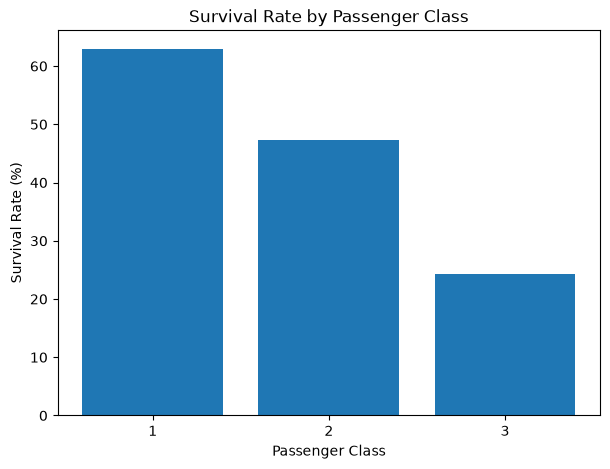

In [14]:
import matplotlib.pyplot as plt

survival_rate = df.groupby("Pclass")["Survived"].mean() * 100

plt.figure(figsize=(7, 5))
plt.bar(survival_rate.index, survival_rate.values)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.xticks([1, 2, 3])

plt.show()

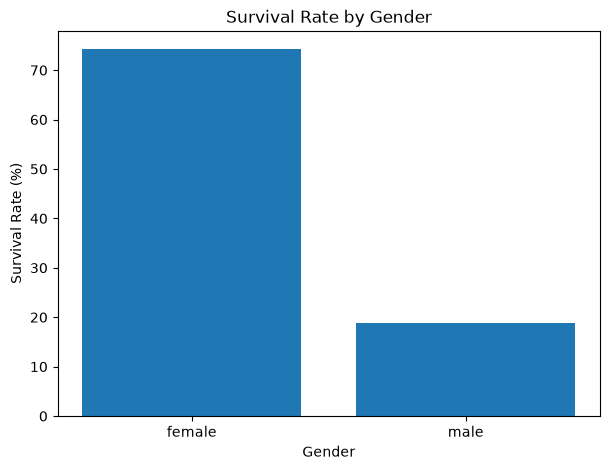

In [15]:
# Survival rate by gender

gender_survival = df.groupby("Sex")["Survived"].mean() * 100

plt.figure(figsize=(7, 5))
plt.bar(gender_survival.index, gender_survival.values)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")

plt.show()

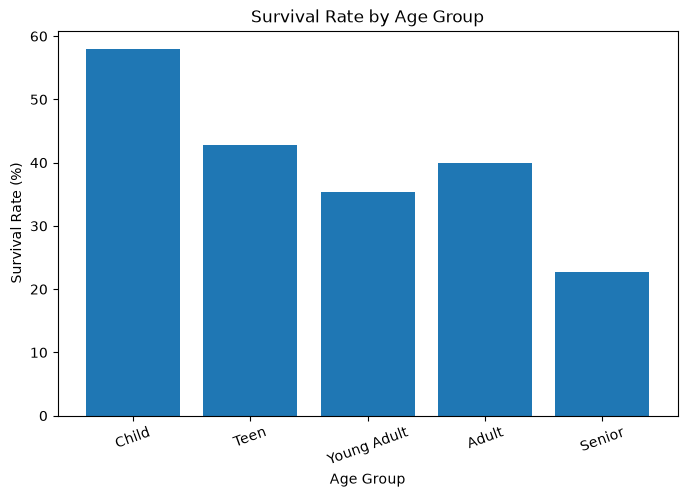

In [16]:
# Survival rate by age group

age_survival = df.groupby(
    "AgeGroup",
    observed=True
)["Survived"].mean() * 100

plt.figure(figsize=(8, 5))
plt.bar(age_survival.index, age_survival.values)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=20)

plt.show()

In [17]:
# Select features for the machine learning model

features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = df[features]
y = df["Survived"]

print("Features selected:")
print(X.head())

print("\nTarget values:")
print(y.head())

Features selected:
   Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0       3    male  22.0      1      0   7.2500        S
1       1  female  38.0      1      0  71.2833        C
2       3  female  26.0      0      0   7.9250        S
3       1  female  35.0      1      0  53.1000        S
4       3    male  35.0      0      0   8.0500        S

Target values:
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


In [18]:
# Convert categorical features into numerical values

X_encoded = pd.get_dummies(
    X,
    columns=["Sex", "Embarked"],
    drop_first=True,
    dtype=int
)

print("Encoded Features:")
print(X_encoded.head())

print("\nFeature Names:")
print(X_encoded.columns.tolist())

Encoded Features:
   Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  Embarked_S
0       3  22.0      1      0   7.2500         1           0           1
1       1  38.0      1      0  71.2833         0           0           0
2       3  26.0      0      0   7.9250         0           0           1
3       1  35.0      1      0  53.1000         0           0           1
4       3  35.0      0      0   8.0500         1           0           1

Feature Names:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training data:
X_train: (712, 8)
y_train: (712,)

Testing data:
X_test: (179, 8)
y_test: (179,)


In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [21]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Predicted values:")
print(y_pred[:10])

print("\nActual values:")
print(y_test.values[:10])

Predicted values:
[0 0 0 0 1 0 1 0 0 0]

Actual values:
[0 0 1 0 1 1 1 0 0 0]


In [22]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 0.8044692737430168
Accuracy Percentage: 80.44692737430168 %


In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[98 12]
 [23 46]]


In [24]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)

print("Classification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



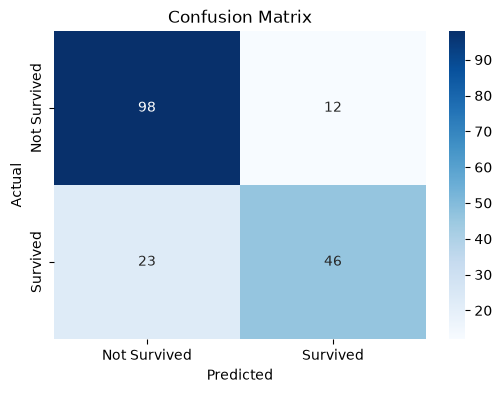

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Survived", "Survived"],
    yticklabels=["Not Survived", "Survived"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

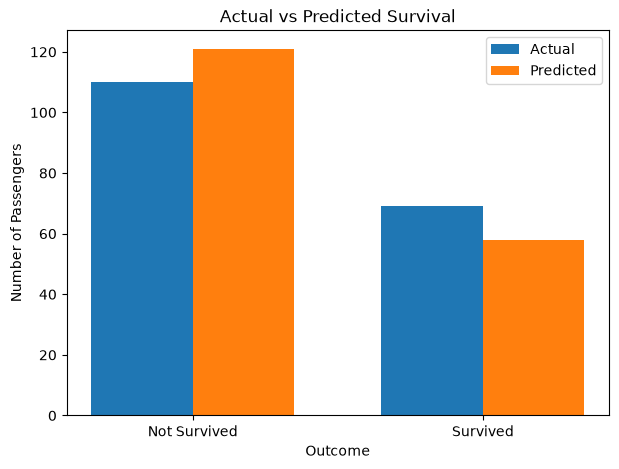

In [26]:
import matplotlib.pyplot as plt
import numpy as np

actual_counts = np.bincount(y_test)
predicted_counts = np.bincount(y_pred)

labels = ["Not Survived", "Survived"]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(7, 5))

plt.bar(x - width/2, actual_counts, width, label="Actual")
plt.bar(x + width/2, predicted_counts, width, label="Predicted")

plt.xlabel("Outcome")
plt.ylabel("Number of Passengers")
plt.title("Actual vs Predicted Survival")
plt.xticks(x, labels)
plt.legend()

plt.show()

In [27]:
print("Actual counts:")
print(np.bincount(y_test))

print("\nPredicted counts:")
print(np.bincount(y_pred))

Actual counts:
[110  69]

Predicted counts:
[121  58]
